In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sys

## Tracé des données biome par biome

In [2]:
df_mnkc = pd.read_csv("/data/rd_exchange/asauvebois/dataset_global/df_micronekton.csv", index_col='date', parse_dates= True)


on choisi les paramètres

In [3]:
biomass_selected = "mnkc_hmlmeso"
biome_selected = 4.0
print(df_mnkc.index.dtype)

datetime64[us]


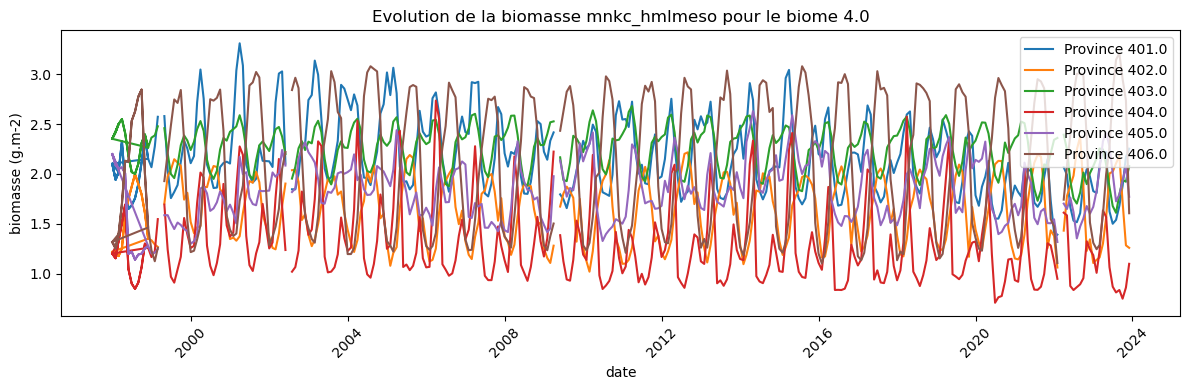

In [4]:
df_by_biome= df_mnkc[df_mnkc["Biome"] == biome_selected]

plt.figure(figsize = (12,4))

#on va tracer une courbe par province appartenant au biome choisi

for prov_id in df_by_biome['prov'].unique():
    df_prov= df_by_biome[df_by_biome['prov'] == prov_id]
    plt.plot(df_prov.index, df_prov[biomass_selected], label= f"Province {prov_id}")

plt.title(f"Evolution de la biomasse {biomass_selected} pour le biome {biome_selected}")
plt.xlabel("date")
plt.ylabel("biomasse (g.m-2)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



on vérifie si les fichiers ont des Nans qui fausseraient les valeurs

In [ ]:
mask_nan = df_mnkc.isna().any(axis=1)
print(df_mnkc[mask_nan])

## Test avec un dataset sur 3 ans

In [7]:
provinces_folder = Path("/data/rd_exchange/asauvebois/dataset_biome") 
micronekton_folder = Path("/data/rd_exchange/asauvebois/mean_month")

variables_mnkc= ["mnkc_epi", "mnkc_umeso", "mnkc_lmeso", "mnkc_mumeso", "mnkc_mlmeso", "mnkc_hmlmeso"]


rows = []

In [8]:
for mnkc_file in sorted(micronekton_folder.glob("*_monthly_mean.nc")):

#on va extraire l'année et le mois depuis le nom du fichier
    year_str = mnkc_file.stem.split("_")[0]
    month_str = mnkc_file.stem.split("_")[1]
    print(f"\nTraitement {year_str}-{month_str}...")


#Fichier province correspondant

    prov_file = provinces_folder/f"provinces_Y{year_str}_M{month_str}.nc"

    if not prov_file.exists():
        print(f"   → Province manquante, on passe")
        continue

#on charge les deux datasets

    ds_mnkc = xr.open_dataset(mnkc_file)
    ds_prov = xr.open_dataset(prov_file)
    
    provinces = ds_prov["province"].values
    prov_list = list(set(provinces.flatten()))

#on boucle sur les provinces 
    prov_list = [p for p in set(provinces.flatten()) if not np.isnan(p)]

    for prov_id in prov_list:
        mask = (provinces == prov_id) #true si on est dans cette province
        biome_values = ds_prov["Biome"].values[mask]
        if len(biome_values) == 0:
            continue
        biome_id = ds_prov["Biome"].values[mask][0] #on prend toutes les valeurs de biome où le masque est true, et on prend la première car toutes les cases d'une même province ont le même biome
       
        row = {
            "date": f"{year_str}-{month_str}",
            "prov": prov_id,
            "Biome": biome_id
        }

#Puis on fait la moyenne spatiale de chaque variable sur la province

        for var in variables_mnkc:
            valeur = ds_mnkc[var].where(mask).mean().values
            row[var] = float(valeur)

        rows.append(row)


    ds_mnkc.close()
    ds_prov.close()


#création du Dataset
df_test = pd.DataFrame(rows)
df_test = df_test.set_index('date')
print(df_test)





Traitement 1998-01...


KeyboardInterrupt: 

In [ ]:
df_test.to_csv("/data/rd_exchange/asauvebois/df_micronekton_test.csv")

NameError: name 'df' is not defined

In [ ]:
df_mnkc_test = pd.read_csv("/data/rd_exchange/asauvebois/dataset_global/df_micronekton_test.csv", index_col='date', parse_dates= True)


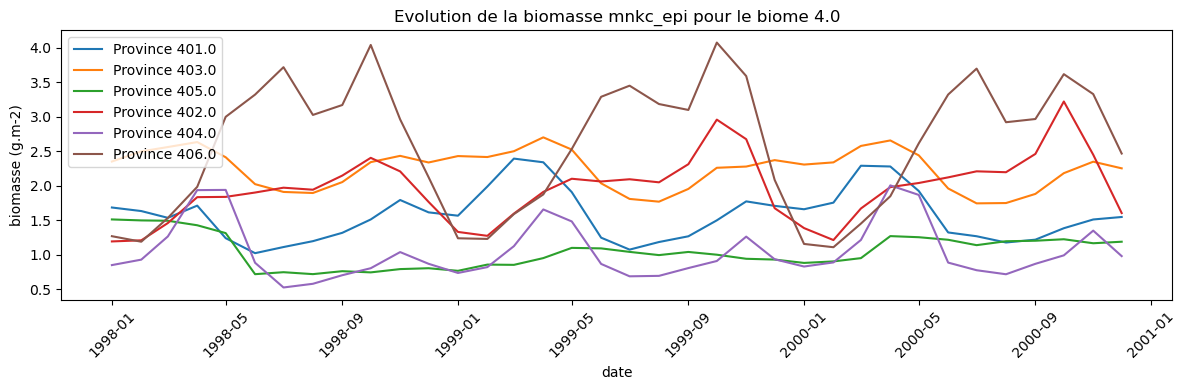

In [ ]:
df_by_biome_test= df_mnkc_test[df_mnkc_test["Biome"] == biome_selected]

plt.figure(figsize = (12,4))

#on va tracer une courbe par province appartenant au biome choisi

for prov_id in df_by_biome_test['prov'].unique():
    df_prov= df_by_biome_test[df_by_biome_test['prov'] == prov_id]
    plt.plot(df_prov.index, df_prov[biomass_selected], label= f"Province {prov_id}")

plt.title(f"Evolution de la biomasse {biomass_selected} pour le biome {biome_selected}")
plt.xlabel("date")
plt.ylabel("biomasse (g.m-2)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

